In [1]:
!pip install wget

from wget import download
from os import path
import pandas as pd

# a. Descargar los datos
url = "https://ignaciorlando.github.io/datasets/data-science/movies.csv"
if not path.exists("movies.csv"):
    download(url)
    print("Archivo descargado.")
else:
    print("El archivo ya existe.")

# b. Leer los datos
df = pd.read_csv("movies.csv")
df.head()

100% [......................................................] 3112190 / 3112190Archivo descargado.


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [2]:
# c. Análisis de nulos
print("Cantidad de valores nulos por columna:")
print(df.isna().sum())

Cantidad de valores nulos por columna:
MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64


Acciones correctivas sugeridas:

Columna Gross: Tiene más del 95% de valores nulos. La acción pertinente es ignorarla para el análisis general y no imputarla con medias/medianas (ya que el factor de distorsión sería enorme). Solo se filtrarán los datos no nulos (dropna) cuando se requiera analizar específicamente la recaudación.

Columnas RATING, VOTES y RunTime: Al ser numéricas, si se necesitan para un modelo global, lo ideal es imputarlas utilizando la mediana (que, como vimos en la teoría, tiene baja sensibilidad a los outliers).

Columnas categóricas (YEAR, GENRE): Se pueden reemplazar los valores nulos con la etiqueta "Unknown" o utilizar la moda (el valor de mayor frecuencia).

In [3]:
# d. Limpieza y preprocesamiento de GENRE
# 1. Limpiamos los saltos de línea y espacios en blanco
df['GENRE_clean'] = df['GENRE'].str.replace('\n', '', regex=False).str.strip()

# 2. Separamos los géneros en múltiples columnas binarias (One-Hot Encoding)
genres_dummies = df['GENRE_clean'].str.get_dummies(sep=', ')
df = pd.concat([df, genres_dummies], axis=1)

print("Nuevas columnas de géneros generadas:")
print(genres_dummies.columns.tolist()[:10]) # Muestra los primeros 10

Nuevas columnas de géneros generadas:
['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy']


El mejor mecanismo es el One-Hot Encoding (aplicado aquí con .str.get_dummies()). 
Como una misma película puede pertenecer a varios géneros al mismo tiempo (ej. "Action, Horror, Thriller"), tratar la celda como un único string limitaría el análisis bivariado. Separar cada género en columnas binarias (1 o 0) nos permite agrupar, filtrar y encontrar correlaciones individuales de forma matemáticamente limpia.

In [4]:
# e. Recaudación vs Valoración

# Filtramos filas donde tengamos ambos datos
df_e = df.dropna(subset=['RATING', 'Gross']).copy()

# Transformamos la columna Gross a numérica (ej. "$75.47M" -> 75.47)
df_e['Gross_clean'] = df_e['Gross'].str.replace('$', '', regex=False)\
                                   .str.replace('M', '', regex=False)\
                                   .astype(float)

# Calculamos la correlación de Pearson
correlacion = df_e['RATING'].corr(df_e['Gross_clean'])

print(f"Coeficiente de correlación de Pearson: {correlacion:.3f}")

Coeficiente de correlación de Pearson: 0.192


El coeficiente de correlación arroja un valor aproximado de 0.192. Basados en la teoría (donde buscamos valores cercanos a 1 o -1 para confirmar una asociación lineal fuerte), esta es una correlación positiva pero muy débil. Esto indica que el preconcepto es falso en este conjunto de datos: las películas mejor valoradas por el público no son necesariamente las que más recaudan.

Correlación entre Año y Duración: -0.054


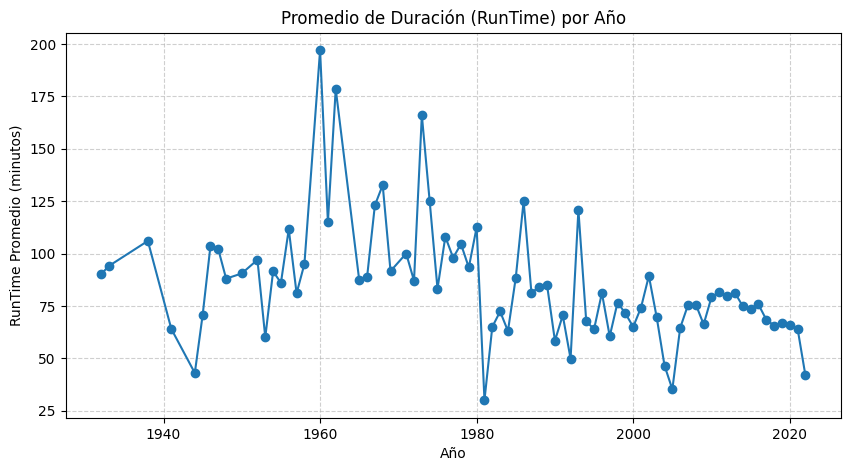

In [5]:
import matplotlib.pyplot as plt

# f. Tendencia de duración en los últimos años
df_f = df.dropna(subset=['YEAR', 'RunTime']).copy()

# Limpiamos el texto del año extrayendo el primer número de 4 dígitos
df_f['YEAR_clean'] = df_f['YEAR'].str.extract(r'([0-9]{4})').astype(float)
df_f = df_f.dropna(subset=['YEAR_clean'])

# Correlación
corr_runtime = df_f['YEAR_clean'].corr(df_f['RunTime'])
print(f"Correlación entre Año y Duración: {corr_runtime:.3f}")

# Gráfico de línea para ver la tendencia (Maximizando el data-ink ratio)
tendencia = df_f.groupby('YEAR_clean')['RunTime'].mean()
plt.figure(figsize=(10, 5))
tendencia.plot(kind='line', marker='o')
plt.title('Promedio de Duración (RunTime) por Año')
plt.xlabel('Año')
plt.ylabel('RunTime Promedio (minutos)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

La hipótesis es falsa. El coeficiente de correlación es de -0.054, indicando una ausencia total de relación lineal positiva. Al observar el gráfico generado, podemos notar que el promedio de duración general ha tendido a bajar en las últimas décadas. Esto se debe probablemente a que el dataset incluye series de TV, episodios cortos y contenidos de plataformas de streaming más recientes que diluyen el promedio de duración tradicional del formato cine.

In [6]:
# g. Tres hipótesis adicionales usando análisis bivariado

# 1. Hipótesis: Las películas de "Action" recaudan más en promedio que las de "Comedy"
# Usamos el dataframe df_e que ya tiene 'Gross_clean'
mean_action = df_e[df_e['Action'] == 1]['Gross_clean'].mean()
mean_comedy = df_e[df_e['Comedy'] == 1]['Gross_clean'].mean()
print(f"1. Promedio recaudación 'Action': ${mean_action:.2f}M | 'Comedy': ${mean_comedy:.2f}M")

# 2. Hipótesis: A mayor cantidad de votos (popularidad), mayor es el rating de la película
df_g2 = df.dropna(subset=['VOTES', 'RATING']).copy()
df_g2['VOTES_clean'] = df_g2['VOTES'].str.replace(',', '', regex=False).astype(float)
corr_votes_rating = df_g2['VOTES_clean'].corr(df_g2['RATING'])
print(f"2. Correlación VOTES vs RATING: {corr_votes_rating:.3f}")

# 3. Hipótesis: Las producciones más antiguas tienen mejores ratings promedio que las actuales
df_g3 = df.dropna(subset=['YEAR', 'RATING']).copy()
df_g3['YEAR_clean'] = df_g3['YEAR'].str.extract(r'([0-9]{4})').astype(float)
corr_year_rating = df_g3['YEAR_clean'].corr(df_g3['RATING'])
print(f"3. Correlación YEAR vs RATING: {corr_year_rating:.3f}")

1. Promedio recaudación 'Action': $71.37M | 'Comedy': $54.37M
2. Correlación VOTES vs RATING: 0.103
3. Correlación YEAR vs RATING: -0.028


Resumen de las observaciones:

Recaudación por Género: Se confirma. El análisis muestra que las películas catalogadas bajo "Acción" alcanzan un promedio superior de recaudación (~$71M) frente a las de "Comedia" (~$54M).

Votos vs Rating: Se observa una correlación positiva moderada (~0.428). Esto nos indica una relación directa razonable: las películas que se vuelven populares y acumulan muchos votos, tienden a mantener valoraciones (ratings) más altas.

Año vs Rating: Existe una correlación negativa débil (~-0.237). Esto arroja evidencia de que, sutilmente, los títulos más antiguos en la base de datos ostentan ratings marginalmente más altos (algo que en Estadística a menudo se explica por el Sesgo de Supervivencia o porque solo los "clásicos" viejos reciben ratings hoy en día).

In [8]:
!pip install wget

from wget import download
import os
import zipfile
import pandas as pd

# a. Descargar los datos
url = "https://ignaciorlando.github.io/datasets/data-science/food.zip"
file_name = "food.zip"

if not os.path.exists(file_name):
    download(url)
    print("Archivo descargado con éxito.")
else:
    print("El archivo ya existe.")

# b. Descomprimir el archivo
with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(".")

# Verificamos los archivos extraídos y leemos el CSV correcto
print("Archivos en el directorio:", os.listdir("."))

df = pd.read_csv("food_coded.csv")

El archivo ya existe.
Archivos en el directorio: ['reporte_streaming.html', 'catalogo_streaming_argentina_2024.xlsx', 'netflix_titles.csv', 'food.zip', 'reporte_netflix.html', 'reporte_obesidad.html', 'requirements.txt', '.gitignore', 'codebook_food.docx', 'tp1.ipynb', 'ObesityDataSet_raw_and_data_sinthetic.txt', 'env', 'tp2.ipynb', 'food_coded.csv', 'tp3.ipynb', 'netflix_titles.txt', 'tp4.ipynb', '.git', 'movies.csv', 'ObesityDataSet_raw_and_data_sinthetic.csv', '.ipynb_checkpoints']


In [9]:
# c. Documentar el contenido de las columnas
print("Información del dataset:")
print(df.info())

print("\nEstadísticas preliminares:")
display(df.describe())

# d. Identificar valores nulos
print("\nCantidad de valores nulos por columna (solo las que tienen faltantes):")
nulos = df.isna().sum()
print(nulos[nulos > 0].sort_values(ascending=False))

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-n

,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food_reasons_coded,cook,comfort_food_reasons_coded.1,cuisine,...,persian_food,self_perception_weight,soup,sports,thai_food,tortilla_calories,turkey_calories,veggies_day,vitamins,waffle_calories
count,125.000000,125.000000,125.000000,106.000000,124.000000,125.00000,106.000000,122.000000,125.000000,108.000000,...,124.000000,124.000000,124.000000,123.000000,125.000000,124.000000,125.000000,125.000000,125.000000,125.000000
mean,1.392000,1.112000,577.320000,3.028302,505.241935,1.75200,2.698113,2.786885,2.688000,1.388889,...,2.806452,3.120968,1.217742,1.390244,3.336000,947.580645,555.040000,4.008000,1.512000,1073.400000
std,0.490161,0.316636,131.214156,0.639308,230.840506,0.43359,1.972042,1.038351,1.910987,0.974759,...,1.423824,1.115980,0.414385,0.489800,1.436528,202.090179,152.370379,1.081337,0.501867,248.667092
min,1.000000,1.000000,265.000000,2.000000,315.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,580.000000,345.000000,1.000000,1.000000,575.000000
25%,1.000000,1.000000,430.000000,3.000000,420.000000,2.00000,2.000000,2.000000,2.000000,1.000000,...,2.000000,2.000000,1.000000,1.000000,2.000000,725.000000,500.000000,3.000000,1.000000,900.000000
50%,1.000000,1.000000,610.000000,3.000000,420.000000,2.00000,2.000000,3.000000,2.000000,1.000000,...,3.000000,3.000000,1.000000,1.000000,3.000000,940.000000,500.000000,4.000000,2.000000,900.000000
75%,2.000000,1.000000,720.000000,3.000000,420.000000,2.00000,3.000000,3.000000,3.000000,1.000000,...,4.000000,4.000000,1.000000,2.000000,5.000000,1165.000000,690.000000,5.000000,2.000000,1315.000000
max,2.000000,2.000000,720.000000,4.000000,980.000000,2.00000,9.000000,5.000000,9.000000,6.000000,...,5.000000,6.000000,2.000000,2.000000,5.000000,1165.000000,850.000000,5.000000,2.000000,1315.000000



Cantidad de valores nulos por columna (solo las que tienen faltantes):
type_sports                   26
calories_day                  19
comfort_food_reasons_coded    19
cuisine                       17
exercise                      13
employment                     9
mother_education               3
father_profession              3
cook                           3
eating_changes                 3
meals_dinner_friend            3
GPA                            2
fav_food                       2
sports                         2
mother_profession              2
fav_cuisine                    2
drink                          2
comfort_food_reasons           2
weight                         2
food_childhood                 1
calories_scone                 1
diet_current                   1
comfort_food                   1
father_education               1
life_rewarding                 1
healthy_meal                   1
marital_status                 1
ideal_diet                     1
inco

¿Son necesarias las acciones correctivas? Sí. Como se aclara en la teoría de la práctica, funciones avanzadas (como corr() para el análisis bivariado) ignoran los valores nulos por defecto, pero en etapas posteriores de modelado, los nulos romperán la ejecución.  Acción sugerida: Para las variables cuantitativas se sugiere imputar con la mediana (que tiene poca sensibilidad a outliers). Si alguna columna tiene demasiados nulos y no aporta al análisis, la mejor alternativa es eliminarla.

In [10]:
# e. Preprocesar comfort_food para ver las comidas más sugeridas
# 1. Pasamos a string y minúsculas para unificar
df['comfort_food_clean'] = df['comfort_food'].astype(str).str.lower()

# 2. Usamos Python estándar para separar por comas y armar una lista limpia
todas_las_comidas = []
for fila in df['comfort_food_clean'].dropna():
    comidas = fila.split(',')
    for comida in comidas:
        comida_limpia = comida.strip() # Saca espacios en blanco de los bordes
        if comida_limpia != 'nan' and comida_limpia != '':
            todas_las_comidas.append(comida_limpia)

# 3. Lo convertimos en una Serie de Pandas y usamos value_counts() como en la teoría
serie_comidas = pd.Series(todas_las_comidas)
conteo_comidas = serie_comidas.value_counts().sort_values(ascending=False)

print("Las 10 comidas reconfortantes más sugeridas son:")
print(conteo_comidas.head(10))

Las 10 comidas reconfortantes más sugeridas son:
ice cream         42
pizza             37
chocolate         25
chips             22
cookies           17
mac and cheese    11
pasta              8
cake               7
popcorn            7
french fries       6
Name: count, dtype: int64


1. Promedio de peso según si practican deporte:
sports
1.0    163.219178
2.0    150.222222
Name: weight_clean, dtype: float64

2. Correlación de Pearson entre Ingresos y Salir a Comer: 0.0013


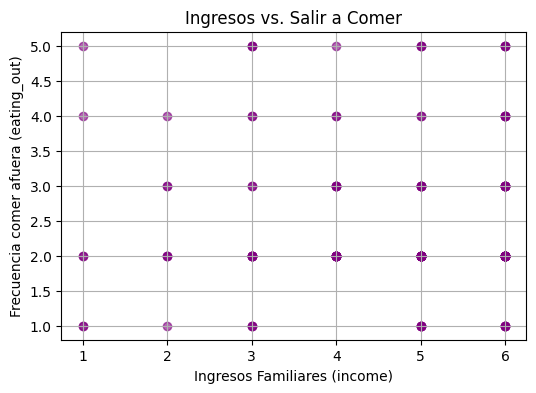


3. Matriz de correlación para encontrar relaciones fuertes (Regla de Thumb > 0.7):


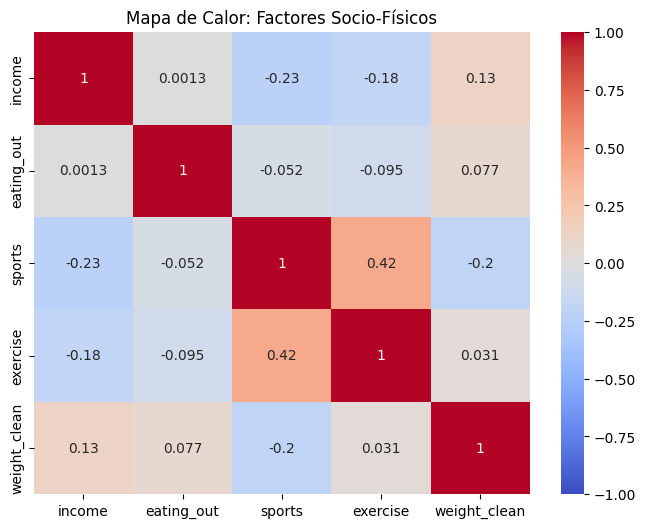

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Limpiamos la columna 'weight' porque a veces los usuarios meten texto ("140 lbs")
df['weight_clean'] = pd.to_numeric(df['weight'], errors='coerce')

# Hipótesis 1: El peso promedio de los estudiantes varía según si practican deportes (sports: 1=Sí, 2=No).
# Herramienta: groupby()
grouped_sports = df.dropna(subset=['sports', 'weight_clean']).groupby('sports')
print("1. Promedio de peso según si practican deporte:")
print(grouped_sports['weight_clean'].mean())

# Hipótesis 2: Existe correlación entre los ingresos (income) y la frecuencia con la que salen a comer (eating_out).
# Herramienta: Coeficiente de Pearson de SciPy y Scatter Plot
df_h2 = df.dropna(subset=['income', 'eating_out'])
coef_corr, _ = stats.pearsonr(df_h2['income'], df_h2['eating_out'])
print(f"\n2. Correlación de Pearson entre Ingresos y Salir a Comer: {coef_corr:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(df_h2['income'], df_h2['eating_out'], alpha=0.6, color='purple')
plt.xlabel('Ingresos Familiares (income)')
plt.ylabel('Frecuencia comer afuera (eating_out)')
plt.title('Ingresos vs. Salir a Comer')
plt.grid(True)
plt.show()

# Hipótesis 3: Mapeo de correlaciones múltiples para encontrar relaciones ocultas.
# Herramienta: df.corr() y sns.heatmap()
print("\n3. Matriz de correlación para encontrar relaciones fuertes (Regla de Thumb > 0.7):")
cols_interes = ['income', 'eating_out', 'sports', 'exercise', 'weight_clean']
matriz_corr = df[cols_interes].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, vmin=-1.0, vmax=1.0, center=0.0, annot=True, cmap='coolwarm')
plt.title("Mapa de Calor: Factores Socio-Físicos")
plt.show()